In [ ]:
!pip install shap

Upload your CSV dataset file:


Saving archive (7).zip to archive (7).zip
Dataset uploaded: archive (7).zip

Dataset head:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6236 - loss: 0.7190 - val_accuracy: 0.9011 - val_loss: 0.4145
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8571 - loss: 0.3689 - val_accuracy: 0.9341 - val_loss: 0.2865
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9066 - loss: 0.2590 - val_accuracy: 0.9341 - val_loss: 0.2228
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9341 - loss: 0.1822 - val_accuracy: 0.9341 - val_loss: 0.1850
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9451 - loss: 0.1460 - val_accuracy: 0.9451 - val_loss: 0.1615
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9533 - loss: 0.1372 - val_accuracy: 0.9451 - val_loss: 0.1468
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9533 - loss: 0.1263 - val_accuracy: 0.9451 - val_loss: 0.1324
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9670 - loss: 0.1303 - val_accuracy: 0.9341 - val_loss

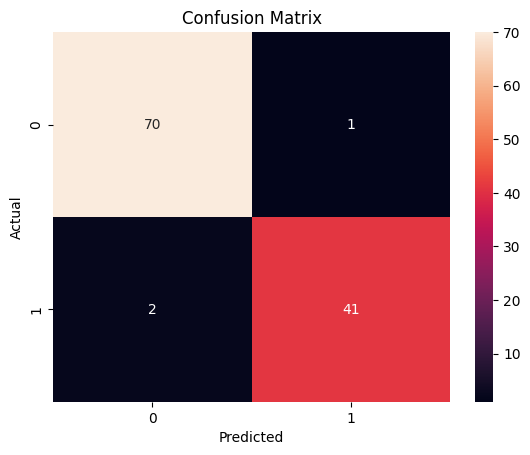

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


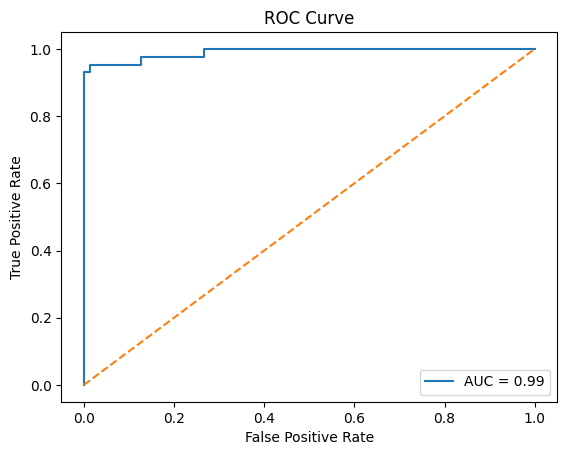


Generating SHAP explanations...


PermutationExplainer explainer: 101it [00:18,  3.50it/s]


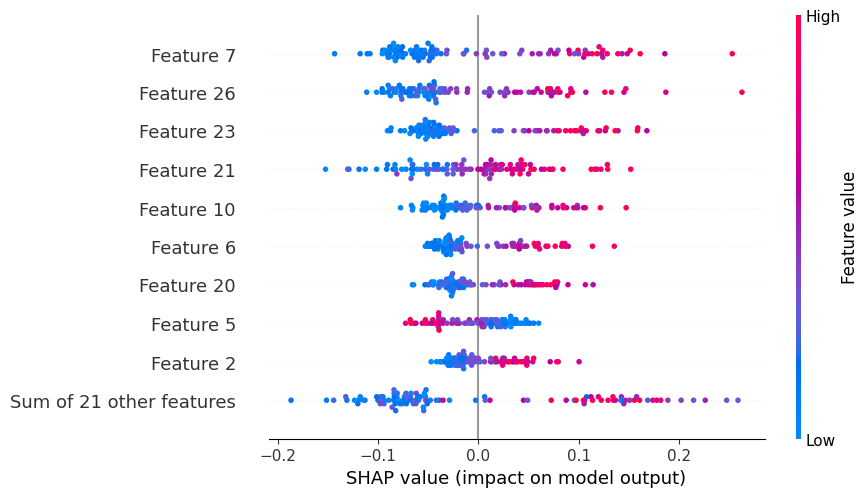

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

Sample Prediction:
High Risk (Malignant) - 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [9]:
# ==========================================
# Breast Cancer Classification - Google Colab
# Deep Learning + SHAP + File Upload
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models
import shap

# ==========================
# 1. Upload Dataset in Colab
# ==========================
from google.colab import files

print("Upload your CSV dataset file:")
uploaded = files.upload()

# Get the first uploaded file
dataset_path = list(uploaded.keys())[0]
print(f"Dataset uploaded: {dataset_path}")

df = pd.read_csv(dataset_path)
print("\nDataset head:")
print(df.head())

# ==========================
# 2. Preprocessing
# ==========================
if 'id' in df.columns:
    df = df.drop(['id'], axis=1)
if 'Unnamed: 32' in df.columns:
    df = df.drop(['Unnamed: 32'], axis=1)

if 'diagnosis' in df.columns:
    df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
else:
    raise ValueError("Dataset must contain 'diagnosis' column with values 'M' or 'B'.")

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================
# 3. Build Deep Learning Model
# ==========================
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ==========================
# 4. Train Model
# ==========================
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# ==========================
# 5. Evaluation
# ==========================
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ==========================
# 6. Confusion Matrix
# ==========================
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================
# 7. ROC Curve
# ==========================
y_probs = model.predict(X_test)
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ==========================
# 8. SHAP Explainability
# ==========================
print("\nGenerating SHAP explanations...")
try:
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_test[:100])
    shap.plots.beeswarm(shap_values)
except Exception as e:
    print("SHAP error, using KernelExplainer instead:", e)
    explainer = shap.KernelExplainer(model.predict, X_train[:100])
    shap_values = explainer.shap_values(X_test[:10])
    shap.plots.beeswarm(shap_values)

# ==========================
# 9. Risk Prediction Function
# ==========================
def predict_risk(input_data):
    input_data = scaler.transform([input_data])
    prob = model.predict(input_data)[0][0]
    if prob > 0.7:
        return f"High Risk (Malignant) - {prob*100:.2f}%"
    elif prob > 0.4:
        return f"Moderate Risk - {prob*100:.2f}%"
    else:
        return f"Low Risk (Benign) - {prob*100:.2f}%"

# ==========================
# 10. Test Sample
# ==========================
sample = X.iloc[0].values
result = predict_risk(sample)
print("\nSample Prediction:")
print(result)